# Notebook to perform Pathway analysis of CosMX RNA Data

# TODO
- 

## Instructions

- 

## Imports

In [128]:
# Load Packages
library(Seurat)
library(readr)
library(dplyr)
library(tidyr)
library(stringr)
library(ggplot2)
library(gridExtra)
library(patchwork)
library(data.table)
library(Matrix)
library(harmony)
library(ggrepel)
library(pals)
library(RColorBrewer)
library(ggrastr)
library(cluster)
library(ggrepel)
library(gtools)
library(tibble)
library(scPearsonPCA)
library(fs)
library(InSituCor)
library(pheatmap)
library(grid)
library(ComplexHeatmap)
library(viridis)
library(circlize)
library(AUCell)
library(tictoc)
library(readxl)
# library(reshape2)

In [129]:
# Load helper functions
source("helper_functions.R")

## Data Loading

In [130]:
# Define directories
seu_file_path <- file.path("../outputs/TMA18/seurat_objects/annotated_object_TMA18_louvain_final.RDS")
out_dir <- "../outputs" # Folder for outputs
study_name <- "TMA18"
out_dir_seu <- file.path(out_dir, study_name, "seurat_objects")
full_out_dir <- file.path(out_dir, study_name, "PW")
dir.create(full_out_dir, showWarnings = FALSE, recursive = TRUE)
dir.create(out_dir_seu, showWarnings = FALSE, recursive = TRUE)

Define Parameters

In [131]:
ASSAY_NAME <- "RNA"
reduction <- "scpearson_umap_nobatch"
sdimx_col <- "x_slide_mm"
sdimy_col <- "y_slide_mm"
study_id_col <- "study_id"
region_col <- "region"
annotation_col <- "final_annotation"
# annotation_col <- "broad_annotation"

# Subset
subset <- FALSE

Loading Seurat object

In [132]:
# Load Seurat object
seu <- readRDS(seu_file_path)

In [133]:
# colnames(seu@meta.data)
head(seu@meta.data, n=5)

,fov,Area,AspectRatio,x_FOV_px,y_FOV_px,Width,Height,Mean.PanCK,Max.PanCK,Mean.G,⋯,GABAergic.synapse,Gap.Junctions,Glutamatergic.synapse,Microglia.Neurodegenerative.Phenotype..MGnD.,Myelogenesis,Neuroactive.Ligands.and.Receptors,Neurogenesis,Oligodendrocyte.Differentiation,Transmitter.Response,Transmitter.Storage
,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
18_c_1_100_100,100,23200,0.79,1848,915,207,164,1099.8,3272,371.9,⋯,0.006024423,0.0131398,0.01469979,0.05543288,0.032258065,0.02618235,0.1541420,0.03852814,0.040985700,0.01833722
18_c_1_100_107,100,2805,0.92,1713,926,57,62,1391.7,3480,366.9,⋯,0.001465400,0.0000000,0.03648033,0.05962080,0.007141098,0.04905111,0.2053335,0.01202501,0.024940415,0.00000000
18_c_1_100_123,100,6857,0.73,584,1043,83,113,871.4,1332,340.7,⋯,0.010094980,0.0000000,0.02380952,0.02489911,0.038167939,0.01947987,0.1716261,0.02886003,0.028515492,0.01289821
18_c_1_100_157,100,8809,0.99,2257,1291,109,110,782.8,4068,274.9,⋯,0.019158752,0.0000000,0.03763975,0.03236123,0.023844702,0.01927904,0.1925356,0.03477633,0.034048349,0.03139083
18_c_1_100_171,100,6681,0.94,1935,1398,89,95,11505.6,34672,237.2,⋯,0.040000000,0.0145149,0.03138716,0.06000152,0.039440204,0.01044282,0.1824066,0.06474266,0.008469527,0.00000000


Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


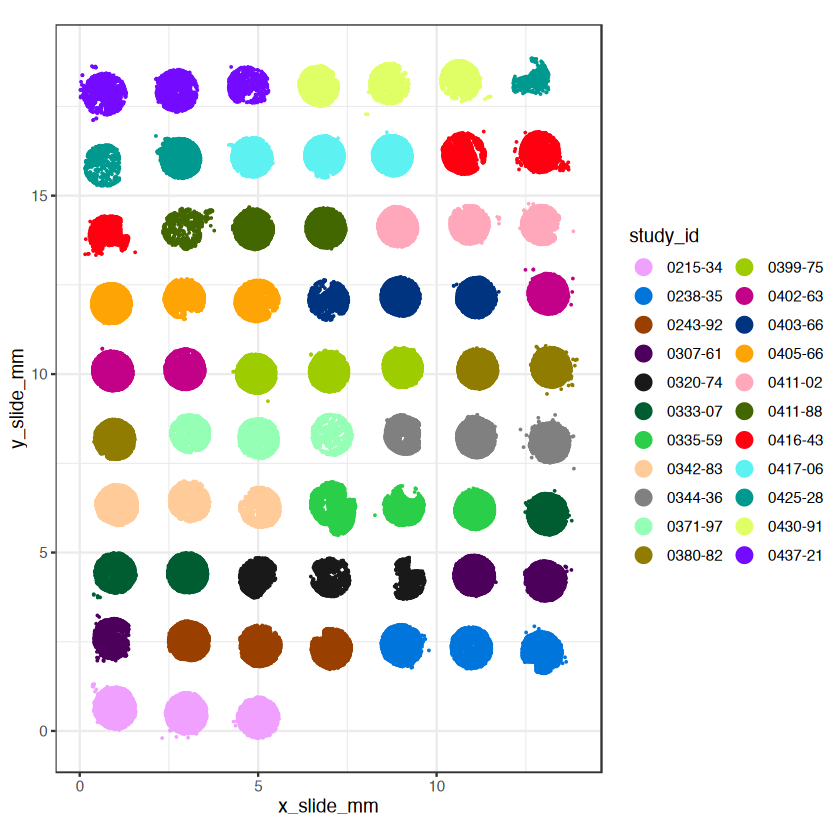

In [134]:
# Visualize the data
xyplot(study_id_col, metadata = seu@meta.data, ptsize = 0.01) + coord_fixed()

In [135]:
unique(seu@meta.data[[study_id_col]])
unique(seu@meta.data[[region_col]])

[1] "0411-88" "0405-66" "0402-63" "0425-28" "0371-97" "0342-83" "0333-07"
 [8] "0243-92" "0215-34" "0437-21" "0416-43" "0417-06" "0399-75" "0320-74"
[15] "0430-91" "0403-66" "0335-59" "0411-02" "0344-36" "0238-35" "0380-82"
[22] "0307-61"

[1] 13 14 15 2  16 17 18 19 20 21 3  22 23 24 25 26 1  27 28 29 30 31 32 4  33
[26] 34 35 36 37 38 39 40 41 42 5  43 44 45 46 47 48 49 50 51 52 6  53 54 55 56
[51] 57 58 59 60 61 62 63 7  64 65 66 8  9  10 11 12
66 Levels: 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 ... 66

Setting

In [136]:
if (subset) {

    # Filter for one patient only
    seu <- subset(seu, subset = study_id %in% c("0238-35"))

    # Filter for one region only
    # seu <- subset(seu, subset = region %in% c("18_C9"))

}

# Drop unused levels
seu@meta.data[[region_col]] <- droplevels(seu@meta.data[[region_col]])

Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


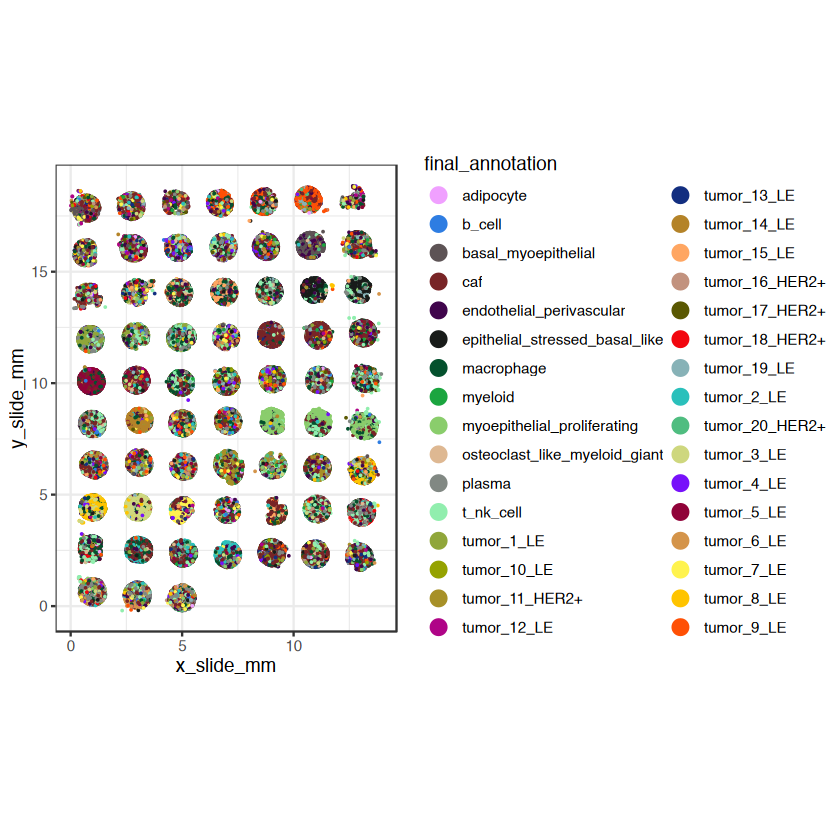

In [137]:
# Visualize the data
xyplot(annotation_col, metadata = seu@meta.data, ptsize = 0.01) + coord_fixed()

In [138]:
nrow(seu)
ncol(seu)

[1] 6175

[1] 189704

Prepare the data

In [139]:
# Counts Data
counts <- Matrix::t(seu[[ASSAY_NAME]]$counts)
neg_counts <- Matrix::t(seu[["negprobes"]]$counts)
metadata <- seu@meta.data # row-aligned with the counts matrix
metadata$neg_total_counts <- Matrix::rowSums(neg_counts)
metadata$negmean <- Matrix::rowMeans(neg_counts)
xy <- as.matrix(metadata[, c(sdimx_col, sdimy_col)])

# Quick check: are the cell IDs of 'counts', 'metadata', and 'xy' in the same order?
all(rownames(counts) == rownames(metadata))
all(rownames(counts) == rownames(xy))

## normalize counts matrix using efficient sparse matrix calls:
scale_row <- mean(metadata$nCount_RNA) / metadata$nCount_RNA
norm <- counts
norm@x <- norm@x * scale_row[norm@i + 1L]

[1] TRUE

[1] TRUE

# Gene Sets

In [140]:
library(msigdbr)
library(progeny)

### REACTOME

In [105]:
# Get REACTOME pathways
# Mouse species = "Mus musculus"
gene_set_name <- "REACTOME"
gene_sets_db_reactome <- msigdbr(species = "Homo sapiens", collection = "C2", subcollection = "CP:REACTOME")


### Hallmark

In [141]:
# Get Hallmark gene sets
gene_set_name <- "HALLMARK"
gene_sets_db_hallmark <- msigdbr(species = "Homo sapiens", collection = "H")

### Progeny

In [165]:
# Load PROGENy gene sets (top N genes per pathway)
gene_set_name <- "PROGENY"
top_n <- 300

# Get PROGENy model for human with top 100 genes
progeny_model <- progeny::getModel(organism = "Human", top = top_n)

# Convert to format compatible with AUCell (list of gene sets)
gene_sets_db_progeny <- list()
for(pathway in colnames(progeny_model)) {
  # Get genes with weights for this pathway and take top 100 by absolute weight
  genes <- rownames(progeny_model)[order(abs(progeny_model[, pathway]), decreasing = TRUE)][1:top_n]
  genes <- genes[!is.na(genes)]  # Remove any NAs
  gene_sets_db_progeny[[pathway]] <- genes
}

### Manually Load Gene Sets (e.g. from COSMX Panel)

In [107]:
# Load COSMX Panel
geneset_path <- "../inputs/6K Plex Human Panel.xlsx"
df <- read_excel(path = geneset_path,
                 sheet = "Neuroscience Annotations",
                 skip = 1)

# pathways of interest
pws <- c(
  "A1 Astrocyte",
  "A2 Astrocyte",
  "Activated Microglia",
  "Astrocyte Differentiation/Function",
  "Axon Structure",
  "Blood Brain Barrier",
  "Cell Cycle",
  "Cholinergic synapse",
  "Dopaminergic synapse",
  "GABAergic synapse",
  "Gap Junctions",
  "Glutamatergic synapse",
  "Microglia Neurodegenerative Phenotype (MGnD)",
  "Myelogenesis",
  "Neuroactive Ligands and Receptors",
  "Neurogenesis",
  "Oligodendrocyte Differentiation",
  "Transmitter Response",
  "Transmitter Storage"
)

# check columns exist
pws <- intersect(pws, colnames(df))

# build named list of genes with "+"
gene.sets_manual <- setNames(
  lapply(pws, function(pw) {
    genes <- df$Gene[df[[pw]] == "+"]
    genes[!is.na(genes)]
  }),
  make.names(pws)
)

### Define gene set to use

In [166]:
gene_set_name_use <- "PROGENY"

# Convert to named list format for AUCell
if (gene_set_name_use == "PROGENY") {
  gene.sets <- gene_sets_db_progeny
} else if (gene_set_name_use == "HALLMARK") {
  gene.sets <- split(gene_sets_db_hallmark$gene_symbol, gene_sets_db_hallmark$gs_name)
} else if (gene_set_name_use == "REACTOME") {
  gene.sets <- split(gene_sets_db_reactome$gene_symbol, gene_sets_db_reactome$gs_name)
} else if (gene_set_name_use == "MANUAL") {
  gene.sets <- gene.sets_manual
} else {
  stop("Unknown gene set name")
}

### Quality Control

Number of pathways: 14

Average number of genes per pathway: 300

Number of unique genes in pathways: 3714

Number of unique genes overlap with data: 1472

Percentage of unique genes in data: 39.6338179859989

Number of pathways (after filtering): 14

Average number of genes per pathway (after filtering): 124.642857142857

Number of unique genes in pathways (after filtering): 1472



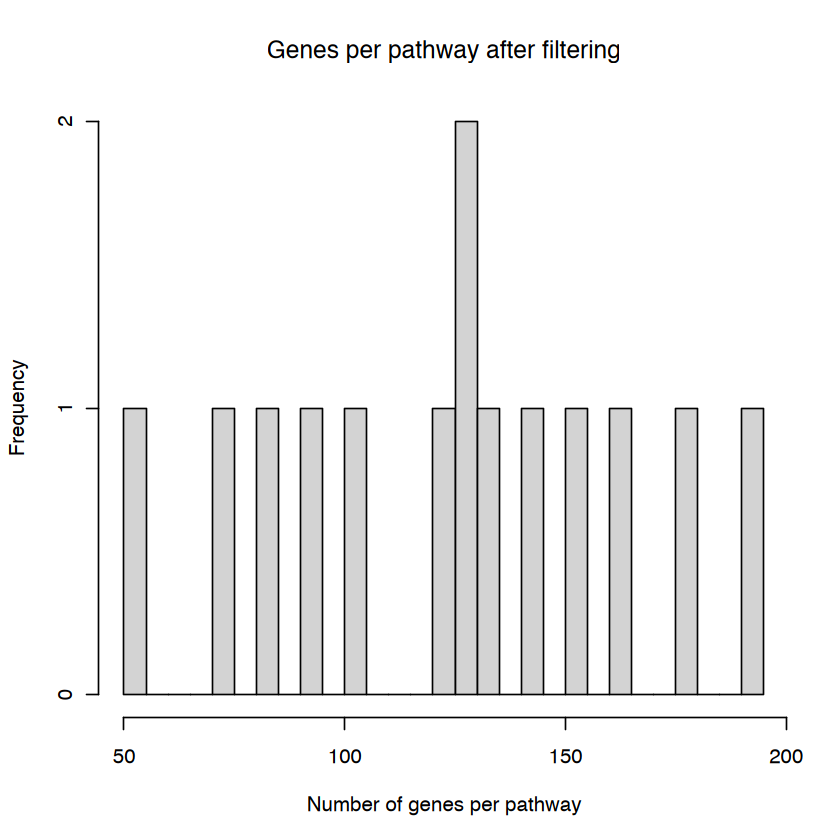

In [167]:
# Params
min_genes_per_pathway <- 5

# Calculate Metrics
n_pathways <- length(gene.sets)
genes_per_pathway <- lengths(gene.sets)
avg_genes_per_pathway <- mean(genes_per_pathway)
unique_genes <- unique(unlist(gene.sets))
n_unique_genes <- length(unique_genes)
# overlap with data
genes_in_data <- colnames(counts)
overlap_genes <- intersect(unique_genes, genes_in_data)
n_overlap <- length(overlap_genes)
percentage_overlap <- (n_overlap / n_unique_genes) * 100

# Print metrics
message(paste0("Number of pathways: ", n_pathways))
message(paste0("Average number of genes per pathway: ", avg_genes_per_pathway))
message(paste0("Number of unique genes in pathways: ", n_unique_genes))
message(paste0("Number of unique genes overlap with data: ", n_overlap))
message(paste0("Percentage of unique genes in data: ", percentage_overlap))

# Filter pathways
# keep only genes present in data
gene.sets.filtered <- lapply(
  gene.sets,
  function(gs) intersect(gs, genes_in_data)
)

# remove gene sets with < 10 genes
gene.sets.filtered <- gene.sets.filtered[
  lengths(gene.sets.filtered) >= min_genes_per_pathway
]

# Calculate Metrics
n_pathways <- length(gene.sets.filtered)
genes_per_pathway <- lengths(gene.sets.filtered)
avg_genes_per_pathway <- mean(genes_per_pathway)
unique_genes <- unique(unlist(gene.sets.filtered))
n_unique_genes <- length(unique_genes)
# overlap with data
genes_in_data <- colnames(counts)
overlap_genes <- intersect(unique_genes, genes_in_data)
n_overlap <- length(overlap_genes)
percentage_overlap <- (n_overlap / n_unique_genes) * 100

# Print metrics
message(paste0("Number of pathways (after filtering): ", n_pathways))
message(paste0("Average number of genes per pathway (after filtering): ", avg_genes_per_pathway))
message(paste0("Number of unique genes in pathways (after filtering): ", n_unique_genes))

hist(
  genes_per_pathway,
  breaks = 30,
  # xlim = c(floor(min(genes_per_pathway)), ceiling(max(genes_per_pathway))),
  main = "Genes per pathway after filtering",
  xlab = "Number of genes per pathway"
)

In [168]:
# Clean up
rm(gene_sets_db_reactome, gene_sets_db_hallmark, gene_sets_db_progeny, progeny_model, gene.sets_manual)
names(gene.sets) <- make.names(names(gene.sets))


Warning message in rm(gene_sets_db_reactome, gene_sets_db_hallmark, gene_sets_db_progeny, :
“object 'gene_sets_db_reactome' not found”
Warning message in rm(gene_sets_db_reactome, gene_sets_db_hallmark, gene_sets_db_progeny, :
“object 'gene_sets_db_hallmark' not found”
Warning message in rm(gene_sets_db_reactome, gene_sets_db_hallmark, gene_sets_db_progeny, :
“object 'gene.sets_manual' not found”


In [169]:
if (subset) {

    # Filter for few only
    gene.sets <- gene.sets[1:3]
}


## AUCell

In [170]:
run_aucell_chunked <- function(counts, metadata, gene.sets, 
                                chunk_col = NULL, outdir = ".") {
  
  if (is.null(chunk_col)) {
    message("Running AUCell on entire dataset...")
    tic()
    pathscores <- AUCell::AUCell_run(exprMat = t(counts), geneSets = gene.sets)
    toc()
    return(pathscores)
  }
}

In [171]:
pathscores <- run_aucell_chunked(counts = counts, metadata = metadata, gene.sets = gene.sets)

Running AUCell on entire dataset...



Warning message in .pause_resource():
“omp_pause_resource() failed to relinquish resources on device 0”
Warning message in .AUCell_calcAUC(geneSets = geneSets, rankings = rankings, nCores = nCores, :
“The following gene sets will be excluded from the analysis(less than 20% of their genes are available):
Trail”
Warning message in .pause_resource():
“omp_pause_resource() failed to relinquish resources on device 0”
Warning message in .pause_resource():
“omp_pause_resource() failed to relinquish resources on device 0”
Warning message in .AUCell_calcAUC(geneSets = geneSets, rankings = rankings, nCores = nCores, :
“The following gene sets will be excluded from the analysis(less than 20% of their genes are available):
Trail”
Warning message in .pause_resource():
“omp_pause_resource() failed to relinquish resources on device 0”
Warning message in .pause_resource():
“omp_pause_resource() failed to relinquish resources on device 0”
Warning message in .AUCell_calcAUC(geneSets = geneSets, rankings

134.722 sec elapsed


In [172]:
saveRDS(pathscores, paste0(full_out_dir, paste0("/pathscores_filtered_", study_name, "_", gene_set_name_use, ".RDS")))

In [173]:
dim(pathscores)
# colnames(metadata) 
meta_cols <- c(region_col, annotation_col, study_id_col, sdimy_col, sdimx_col)
meta_cols

[1]     13 189704

[1] "region"           "final_annotation" "study_id"         "y_slide_mm"      
[5] "x_slide_mm"

In [174]:
auc_matrix <- getAUC(pathscores)
auc_df <- as.data.frame(t(auc_matrix))  # cells × pathways

if (nrow(auc_df) != nrow(metadata)) {
  stop("Number of rows in auc_df does not match number of rows in metadata")
}
# Define relevant pathways
pw_cols <- colnames(auc_df)

meta_cols <- c(region_col, annotation_col, study_id_col, sdimy_col, sdimx_col)
auc_df <- cbind(metadata[, meta_cols], auc_df[rownames(metadata),])

# Overview of Pathway Scores

In [175]:
pathway_stats <- calculate_pathway_stats(auc_df, pw_cols)

In [176]:
# Define thresholds
min_mean <- quantile(pathway_stats$mean, 0.9)
min_sd <- quantile(pathway_stats$sd, 0.9)
min_cv <- quantile(pathway_stats$cv, 0.75)

In [177]:
output_file <- file.path(full_out_dir, paste0("Pathway_Distributions_filtered_", study_name, "_", gene_set_name_use,
  "_mm", round(min_mean, 2),
  ".pdf"
))

visualize_pathway_distributions(pathway_stats, min_mean, min_sd, output_file)

agg_record_565442192 
                   2

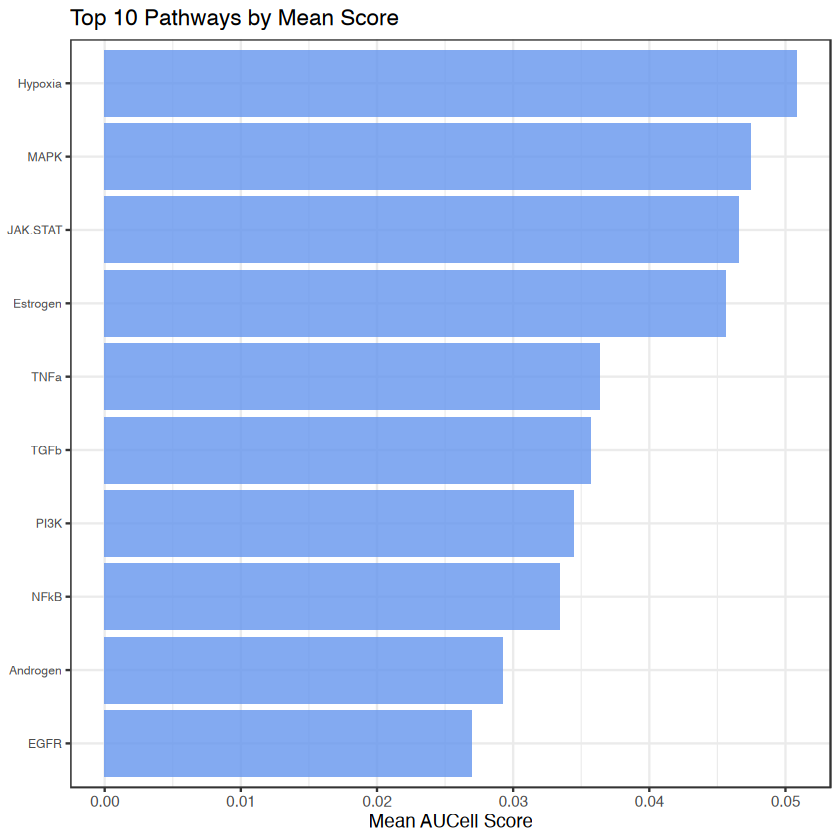

In [178]:
# Ranked mean bar plot (top N for readability)
top_n <- 10
pathway_stats_mean_sorted <- pathway_stats[order(pathway_stats$mean, decreasing = TRUE), ]
pathway_stats_mean_sorted$rank <- 1:nrow(pathway_stats_mean_sorted)
topN_mean <- head(pathway_stats_mean_sorted, top_n)
topN_mean$pathway_short <- gsub("^REACTOME_|^HALLMARK_", "", topN_mean$pathway)

ggplot(topN_mean, aes(x = reorder(pathway_short, mean), y = mean)) +
  geom_bar(stat = "identity", fill = "cornflowerblue", alpha = 0.8) +
#   geom_hline(yintercept = min_mean, color = "red", linetype = "dashed") +
  coord_flip() +
  labs(title = sprintf("Top %d Pathways by Mean Score", top_n),
       x = NULL, y = "Mean AUCell Score") +
  theme_bw() +
  theme(axis.text.y = element_text(size = 7))

# Filtering and adding manual pathways (optional)

In [ ]:
# filtered_pathways <- filter_pathways_basic(pathway_stats, 
#                                    min_mean = min_mean,
#                                    min_sd = min_sd)

Using absolute thresholds: mean > 0.052, sd > 0.032

Pathways passing filters: 3/50 (mean & sd)



In [ ]:
# manual_pathways <- c(
#   # Cell cycle and proliferation
#   "REACTOME_CELL_CYCLE",
#   "REACTOME_MITOTIC_G1_PHASE_AND_G1_S_TRANSITION",
#   "REACTOME_DNA_REPLICATION",

#   # DNA damage and genome stability
#   "REACTOME_DNA_REPAIR",
#   "REACTOME_DNA_DOUBLE_STRAND_BREAK_REPAIR",

#   # Growth factor and oncogenic signaling
#   "REACTOME_SIGNALING_BY_EGFR",
#   "REACTOME_PI3K_AKT_SIGNALING_IN_CANCER",
#   "REACTOME_MAPK_FAMILY_SIGNALING_CASCADES",

#   # Cell death
#   "REACTOME_APOPTOSIS",

#   # Immune checkpoint and interferon
#   "REACTOME_INTERFERON_SIGNALING"
# )

# # Check why manual pathways failed
# manual_stats <- pathway_stats[pathway_stats$pathway %in% manual_pathways, ]
# manual_stats <- manual_stats[order(manual_stats$mean), ]
# manual_stats

# manual_pathways

,pathway,mean,median,sd,cv,min,max,range,mean_percentile,sd_percentile,cv_percentile
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
REACTOME_PI3K_AKT_SIGNALING_IN_CANCER,REACTOME_PI3K_AKT_SIGNALING_IN_CANCER,0.02713792,0.02583960,0.01397506,0.5149645,0.0000000000,0.1091383,0.1091383,0.4714372,0.013229104,0.082381239
REACTOME_DNA_DOUBLE_STRAND_BREAK_REPAIR,REACTOME_DNA_DOUBLE_STRAND_BREAK_REPAIR,0.02946510,0.02794842,0.01509794,0.5124007,0.0000000000,0.1230625,0.1230625,0.5303668,0.031268791,0.081779916
REACTOME_MITOTIC_G1_PHASE_AND_G1_S_TRANSITION,REACTOME_MITOTIC_G1_PHASE_AND_G1_S_TRANSITION,0.03232973,0.03080873,0.01490263,0.4609574,0.0000000000,0.1274810,0.1274810,0.6001203,0.027660854,0.053517739
REACTOME_SIGNALING_BY_EGFR,REACTOME_SIGNALING_BY_EGFR,0.03340819,0.03143992,0.02086940,0.6246792,0.0000000000,0.1741350,0.1741350,0.6313891,0.160553217,0.155742634
REACTOME_DNA_REPAIR,REACTOME_DNA_REPAIR,0.03379651,0.03291236,0.01258384,0.3723413,0.0000000000,0.1054344,0.1054344,0.6380036,0.003006615,0.022248948
REACTOME_DNA_REPLICATION,REACTOME_DNA_REPLICATION,0.03548610,0.03265188,0.01911726,0.5387253,0.0000000000,0.1703388,0.1703388,0.6728803,0.112447384,0.091401082
REACTOME_APOPTOSIS,REACTOME_APOPTOSIS,0.04761873,0.04575419,0.01982578,0.4163442,0.0000000000,0.1489720,0.1489720,0.8634997,0.131088394,0.032471437
REACTOME_MAPK_FAMILY_SIGNALING_CASCADES,REACTOME_MAPK_FAMILY_SIGNALING_CASCADES,0.04818484,0.04772877,0.01349808,0.2801313,0.0007241606,0.1107966,0.1100724,0.8689116,0.008418521,0.009019844
REACTOME_INTERFERON_SIGNALING,REACTOME_INTERFERON_SIGNALING,0.05625841,0.05232719,0.02342236,0.4163353,0.0008986175,0.2332719,0.2323733,0.9242333,0.241130487,0.031870114


[1] "REACTOME_CELL_CYCLE"                          
 [2] "REACTOME_MITOTIC_G1_PHASE_AND_G1_S_TRANSITION"
 [3] "REACTOME_DNA_REPLICATION"                     
 [4] "REACTOME_DNA_REPAIR"                          
 [5] "REACTOME_DNA_DOUBLE_STRAND_BREAK_REPAIR"      
 [6] "REACTOME_SIGNALING_BY_EGFR"                   
 [7] "REACTOME_PI3K_AKT_SIGNALING_IN_CANCER"        
 [8] "REACTOME_MAPK_FAMILY_SIGNALING_CASCADES"      
 [9] "REACTOME_APOPTOSIS"                           
[10] "REACTOME_INTERFERON_SIGNALING"

In [ ]:
# final_pw_res <- merge_pathway_lists(filtered_pathways, manual_pathways, pw_cols)

Final pathway count: 79

  - From filtering only: 69

  - From manual list only: 10

  - In both lists: 0



In [ ]:
# # Then take top N by SD
# top_n <- 10
# final_pathways <- filtered_pathways[order(pathway_stats$sd[pathway_stats$pathway %in% filtered_pathways], decreasing = TRUE)][1:top_n]
# final_pathways

[1] "REACTOME_MYOCLONIC_EPILEPSY_OF_LAFORA"                                                                
 [2] "REACTOME_DEFECTS_OF_PLATELET_ADHESION_TO_EXPOSED_COLLAGEN"                                            
 [3] "REACTOME_ENHANCED_BINDING_OF_GP1BA_VARIANT_TO_VWF_MULTIMER_COLLAGEN"                                  
 [4] "REACTOME_MODULATION_BY_MTB_OF_HOST_IMMUNE_SYSTEM"                                                     
 [5] "REACTOME_ENDOSOMAL_VACUOLAR_PATHWAY"                                                                  
 [6] "REACTOME_TFAP2A_ACTS_AS_A_TRANSCRIPTIONAL_REPRESSOR_DURING_RETINOIC_ACID_INDUCED_CELL_DIFFERENTIATION"
 [7] "REACTOME_UPTAKE_AND_FUNCTION_OF_DIPHTHERIA_TOXIN"                                                     
 [8] "REACTOME_SIGNALING_BY_MST1"                                                                           
 [9] "REACTOME_RHO_GTPASES_ACTIVATE_RHOTEKIN_AND_RHOPHILINS"                                                
[10] "REACTOME_ACROSOME_REACTION_AND_SPERM_OOCYTE_MEMBRANE_BINDING"

# Add data to seurat Object

In [179]:
# pw_cols_use <- manual_pathways
# pw_cols_use <- final_pathways
pw_cols_use <- pw_cols

In [180]:
# Verify alignment
if (!all(rownames(seu@meta.data) == rownames(auc_df))) {
  stop("Row names don't match between seu@meta.data and auc_df")
}

seu@meta.data[, pw_cols_use] <- auc_df[rownames(seu@meta.data), pw_cols_use]

# Clean names
colnames(seu@meta.data) <- gsub("^REACTOME_|^HALLMARK_", "PW_", colnames(seu@meta.data))
pw_cols_use <- gsub("^REACTOME_|^HALLMARK_", "PW_", pw_cols_use)
colnames(auc_df) <- gsub("^REACTOME_|^HALLMARK_", "PW_", colnames(auc_df))

In [181]:
# Load helper functions
source("helper_functions.R")

In [182]:
output_file <- file.path(full_out_dir, paste0("Pathway_plots_summary_spatial_filtered", study_name, "_", gene_set_name_use, ".pdf"))

# Visualize the data
pathway_summary_plots_spatial(pw_cols_use, seu, reduction, cluster_cols = c(annotation_col, region_col, study_id_col), output_file)

Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Coordinate system already present.
ℹ Adding new coordinate syste

agg_record_959344617 
                   2

In [183]:
output_file <- file.path(full_out_dir, paste0("Pathway_plots_summary_aggr_filtered_", study_name, "_", gene_set_name_use, ".pdf"))

# Visualize the data
outs <- pathway_summary_plots_aggr(pw_cols_use, auc_df, cluster_col = annotation_col, output_file)

In [184]:
# Save Seurat Object

seu_file_path_saving <- seu_file_path
saveRDS(seu, file = seu_file_path_saving)

In [185]:
colnames(seu@meta.data)

[1] "fov"                                                                                                          
  [2] "Area"                                                                                                         
  [3] "AspectRatio"                                                                                                  
  [4] "x_FOV_px"                                                                                                     
  [5] "y_FOV_px"                                                                                                     
  [6] "Width"                                                                                                        
  [7] "Height"                                                                                                       
  [8] "Mean.PanCK"                                                                                                   
  [9] "Max.PanCK"                                                                                                    
 [10] "Mean.G"                                                                                                       
 [11] "Max.G"                                                                                                        
 [12] "Mean.Membrane"                                                                                                
 [13] "Max.Membrane"                                                                                                 
 [14] "Mean.CD45"                                                                                                    
 [15] "Max.CD45"                                                                                                     
 [16] "Mean.DAPI"                                                                                                    
 [17] "Max.DAPI"                                                                                                     
 [18] "SplitRatioToLocal"                                                                                            
 [19] "NucArea"                                                                                                      
 [20] "NucAspectRatio"                                                                                               
 [21] "Circularity"                                                                                                  
 [22] "Eccentricity"                                                                                                 
 [23] "Perimeter"                                                                                                    
 [24] "Solidity"                                                                                                     
 [25] "cell_id"                                                                                                      
 [26] "assay_type"                                                                                                   
 [27] "version"                                                                                                      
 [28] "Run_Tissue_name"                                                                                              
 [29] "Panel"                                                                                                        
 [30] "cellSegmentationSetId"                                                                                        
 [31] "cellSegmentationSetName"                                                                                      
 [32] "slide_ID_numeric"                                                                                             
 [33] "x_slide_mm"                                                                                                   
 [34] "y_slide_mm"                                                                                          

# PseudoBulk

In [412]:
# vector of cell types aligned with rows of norm
celltype <- metadata[[annotation_col]]

# factor
celltype <- factor(celltype)

# design matrix: cells × celltypes
M <- sparse.model.matrix(~ 0 + celltype)

# sum expression per celltype
sum_expr <- t(M) %*% norm   # celltypes × genes

# number of cells per celltype
n_cells <- colSums(M)

# divide to get mean
mean_expr <- sum_expr / n_cells

# set rownames
rownames(mean_expr) <- levels(celltype)

In [415]:
pathscores_pseudobulk <- run_aucell_chunked(counts = mean_expr, metadata = metadata, gene.sets = gene.sets)

Running AUCell on entire dataset...

Warning message in .pause_resource():
“omp_pause_resource() failed to relinquish resources on device 0”
Warning message in .AUCell_calcAUC(geneSets = geneSets, rankings = rankings, nCores = nCores, :
“The following gene sets will be excluded from the analysis(less than 20% of their genes are available):
Trail”


0.142 sec elapsed


In [416]:
auc_matrix_pb <- getAUC(pathscores_pseudobulk)
auc_df_pb <- as.data.frame(t(auc_matrix_pb))  # cells × pathways

In [426]:
  # Determine color scale limits from 95th percentile
  plot_title <- "PW Enrichment"
  abs_vals <- abs(as.matrix(auc_df_pb))
  limit_raw <- quantile(abs_vals, 0.95, na.rm = TRUE)
  
  col_fun_raw <- colorRamp2(c(0, limit_raw/2, limit_raw), 
                            c("blue", "white", "red"))
  
  h1 <- Heatmap(as.matrix(auc_df_pb),
                name = "AUCell PseudoBulk\nScore",
                col = col_fun_raw,
                cluster_rows = TRUE,
                cluster_columns = FALSE,
                row_dend_side = "right",
                show_row_dend = TRUE,
                column_names_rot = 90,
                row_names_side = "left",
                column_names_side = "bottom",
                column_names_max_height = unit(16, "cm"),
                column_title = paste0(plot_title, " - Raw AUCell Scores"),
                heatmap_legend_param = list(
                  at = c(0, limit_raw/2, limit_raw),
                  labels = c("0", sprintf("%.2f", limit_raw/2), sprintf("%.2f", limit_raw))
                ))

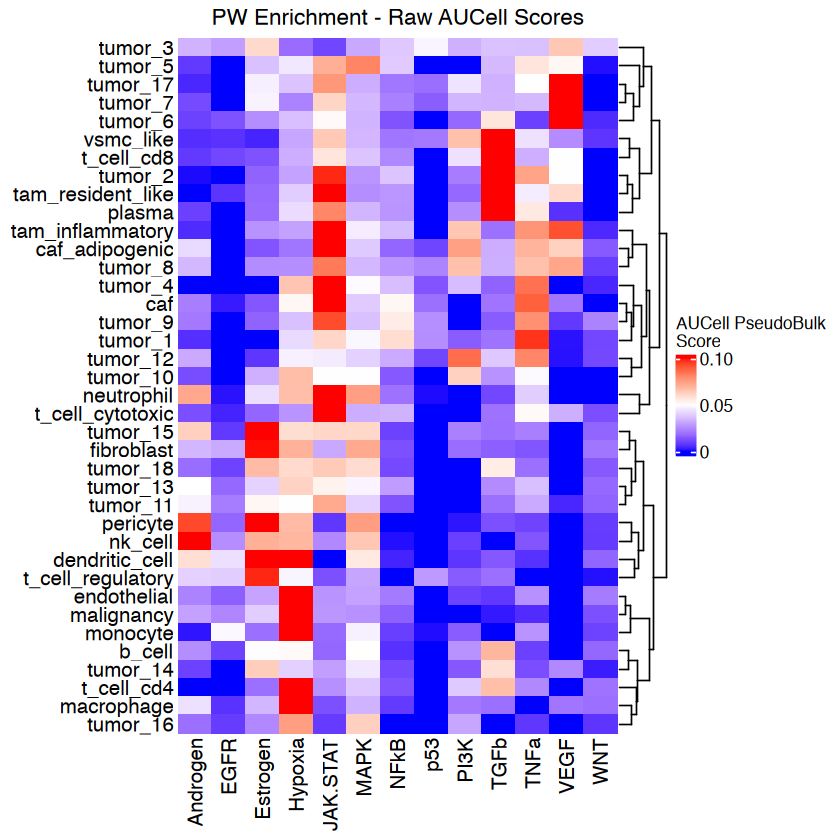

In [425]:
h1

In [126]:
# Define colors
cluster_cls <- InSituType::colorCellTypes(freqs = table(seu@meta.data[annotation_col]), palette = "brewers")

cluster_cls["a"] <- "darkred"
cluster_cls["b"] <- "lightpink"
cluster_cls["c"] <- "firebrick"
cluster_cls["d"] <- "salmon"
cluster_cls["e"] <- "indianred1"
cluster_cls["f"] <- "red"
cluster_cls["g"] <- "darkred"
cluster_cls["h"] <- "tomato"
cluster_cls["i"] <- "mistyrose"
cluster_cls["j"] <- "lightcoral"
cluster_cls["k"] <- "deeppink4"
cluster_cls["l"] <- "orangered3"
cluster_cls["m"] <- "rosybrown1"
cluster_cls["n"] <- "brown3"
cluster_cls["o"] <- "palevioletred1"
cluster_cls["p"] <- "red3"
cluster_cls["q"] <- "peachpuff3"
cluster_cls["r"] <- "darkorange3"
cluster_cls["s"] <- "hotpink3"
cluster_cls["t"] <- "indianred4"
cluster_cls["u"] <- "lavenderblush3"
cluster_cls["v"] <- "red4"
cluster_cls["w"] <- "salmon3"
cluster_cls["x"] <- "maroon3"
cluster_cls["y"] <- "snow3"

# T cell subtypes (shades of blue)
cluster_cls["T.cell.CD8"]       <- "navy"
cluster_cls["T.cell.CD4"]       <- "dodgerblue3"
cluster_cls["T.cell.regulatory"]<- "skyblue"

# Plasma / B cell subtypes (shades of orange)
cluster_cls["Plasma"]           <- "darkorange"
cluster_cls["Plasmablast"]      <- "orange"

# Myeloid subtypes (shades of tan/brown)
cluster_cls["Macrophage"]       <- "tan3"
cluster_cls["Monocyte"]         <- "tan2"
cluster_cls["Neutrophil"]       <- "wheat4"

# Tumor / malignancy (shades of red)
cluster_cls["tumor"]            <- "firebrick2"
cluster_cls["Malignancy"]       <- "red3"

# NK cell
cluster_cls["NK.cell"]          <- "deepskyblue1"

# Endothelial
cluster_cls["Endothelial"]      <- "mediumorchid1"

# B cell
cluster_cls["b_cell"]           <- "seagreen3"

# Fibroblast
cluster_cls["Fibroblast"]       <- "gray30"

# Dendritic cells (shades of yellow)
cluster_cls["Conventional.dendritic.cell"] <- "goldenrod2"
cluster_cls["Plasmacytoid.dendritic.cell"] <- "gold"

# Pericyte
cluster_cls["Pericyte"]         <- "deeppink1"

# TESTING

$cell_index
18_c_2_175_220 
         37073 

$cell_name
[1] "18_c_2_175_220"

$total_counts
18_c_2_175_220 
          5643

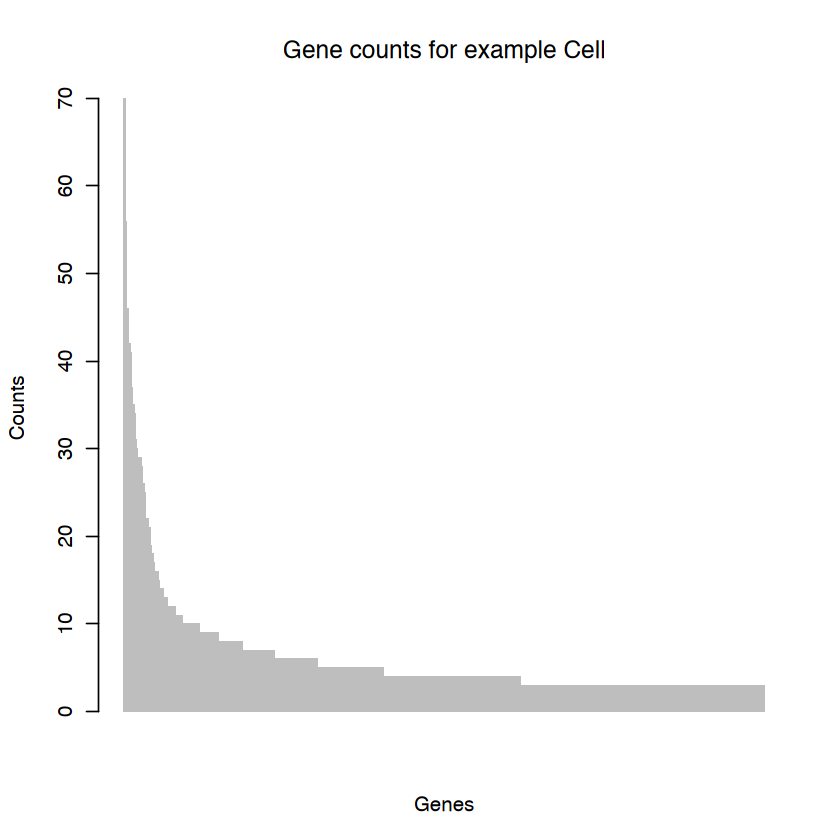

In [459]:
# total counts per cell
total_counts_per_cell <- rowSums(counts)

# index of cell with highest total counts
idx_max <- which.max(total_counts_per_cell)

# corresponding cell name
cell_name_max <- rownames(counts)[idx_max]

# total counts of that cell
max_total_counts <- total_counts_per_cell[idx_max]

list(
  cell_index = idx_max,
  cell_name = cell_name_max,
  total_counts = max_total_counts
)

cell_counts <- counts[idx_max, ]
cell_counts <- as.numeric(cell_counts)
names(cell_counts) <- colnames(counts)

cell_counts_sorted <- sort(cell_counts, decreasing = TRUE)

# log transform
cell_counts_log <- log1p(cell_counts)

# sort high to low
cell_counts_log_sorted <- sort(cell_counts_log, decreasing = TRUE)

# bar plot
barplot(
  cell_counts_sorted[1:500],
  border = NA,
  names.arg = NA,
  main = "Gene counts for example Cell",
  ylab = "Counts",
  xlab = "Genes"
)

In [498]:
colnames(seu@meta.data)

[1] "parent_id"                           
 [2] "Area"                                
 [3] "Area.um2"                            
 [4] "qcCellsFlagged"                      
 [5] "qcCellsPassed"                       
 [6] "Mean.PanCK"                          
 [7] "Max.PanCK"                           
 [8] "Mean.G"                              
 [9] "Max.G"                               
[10] "Mean.Membrane"                       
[11] "Max.Membrane"                        
[12] "Mean.CD45"                           
[13] "Max.CD45"                            
[14] "Mean.DAPI"                           
[15] "Max.DAPI"                            
[16] "fov"                                 
[17] "Run_Tissue_name"                     
[18] "Panel"                               
[19] "updated_cellID"                      
[20] "orig.ident"                          
[21] "nCount_RNA"                          
[22] "nFeature_RNA"                        
[23] "x"                                   
[24] "y"                                   
[25] "z"                                   
[26] "reSeg_action"                        
[27] "cell_ID"                             
[28] "cellID_status"                       
[29] "x_slide_mm"                          
[30] "y_slide_mm"                          
[31] "nCount_negprobes"                    
[32] "nFeature_negprobes"                  
[33] "slide_id"                            
[34] "region"                              
[35] "location"                            
[36] "study_id"                            
[37] "batch"                               
[38] "condition"                           
[39] "cell_ID_new"                         
[40] "IST_clusters_cohort_initial"         
[41] "seurat_clusters"                     
[42] "scpearson_graph_nobatch_res.0.8"     
[43] "scpearson_clusters_nobatch"          
[44] "final_annotation"                    
[45] "broad_annotation"                    
[46] "PW_ADIPOGENESIS"                     
[47] "PW_ALLOGRAFT_REJECTION"              
[48] "PW_ANDROGEN_RESPONSE"                
[49] "PW_ANGIOGENESIS"                     
[50] "PW_APICAL_JUNCTION"                  
[51] "PW_APICAL_SURFACE"                   
[52] "PW_APOPTOSIS"                        
[53] "PW_BILE_ACID_METABOLISM"             
[54] "PW_CHOLESTEROL_HOMEOSTASIS"          
[55] "PW_COAGULATION"                      
[56] "PW_COMPLEMENT"                       
[57] "PW_DNA_REPAIR"                       
[58] "PW_E2F_TARGETS"                      
[59] "PW_EPITHELIAL_MESENCHYMAL_TRANSITION"
[60] "PW_ESTROGEN_RESPONSE_EARLY"          
[61] "PW_ESTROGEN_RESPONSE_LATE"           
[62] "PW_FATTY_ACID_METABOLISM"            
[63] "PW_G2M_CHECKPOINT"                   
[64] "PW_GLYCOLYSIS"                       
[65] "PW_HEDGEHOG_SIGNALING"               
[66] "PW_HEME_METABOLISM"                  
[67] "PW_HYPOXIA"                          
[68] "PW_IL2_STAT5_SIGNALING"              
[69] "PW_IL6_JAK_STAT3_SIGNALING"          
[70] "PW_INFLAMMATORY_RESPONSE"            
[71] "PW_INTERFERON_ALPHA_RESPONSE"        
[72] "PW_INTERFERON_GAMMA_RESPONSE"        
[73] "PW_KRAS_SIGNALING_DN"                
[74] "PW_KRAS_SIGNALING_UP"                
[75] "PW_MITOTIC_SPINDLE"                  
[76] "PW_MTORC1_SIGNALING"                 
[77] "PW_MYC_TARGETS_V1"                   
[78] "PW_MYC_TARGETS_V2"                   
[79] "PW_MYOGENESIS"                       
[80] "PW_NOTCH_SIGNALING"                  
[81] "PW_OXIDATIVE_PHOSPHORYLATION"        
[82] "PW_P53_PATHWAY"                      
[83] "PW_PANCREAS_BETA_CELLS"              
[84] "PW_PEROXISOME"                       
[85] "PW_PI3K_AKT_MTOR_SIGNALING"          
[86] "PW_PROTEIN_SECRETION"                
[87] "PW_REACTIVE_OXYGEN_SPECIES_PATHWAY"  
[88] "PW_SPERMATOGENESIS"                  
[89] "PW_TGF_BETA_SIGNALING"               
[90] "PW_TNFA_SIGNALING_VIA_NFKB"          
[91] "PW_UNFOLDED_PROTEIN_RESPONSE"      